In [47]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [48]:
# Selecting a stock and load historical data
stock_symbol = 'TSLA'
print(f"Loading historical data for {stock_symbol}...")

Loading historical data for TSLA...


In [49]:
# Downloading historical data
data = yf.download(stock_symbol, start='2023-01-01', end='2026-06-21', progress=False)
print(f"Data shape: {data.shape}")
print(f"\nFirst few rows:\n{data.head()}")

Data shape: (868, 5)

First few rows:
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2023-01-03  108.099998  118.800003  104.639999  118.470001  231402800
2023-01-04  113.639999  114.589996  107.519997  109.110001  180389000
2023-01-05  110.339996  111.750000  107.160004  110.510002  157986300
2023-01-06  113.059998  114.389999  101.809998  103.000000  220911100
2023-01-09  119.769997  123.519997  117.110001  118.959999  190284000


In [50]:
# Step 2: Preparing features (Open, High, Low, Volume) and target (Close)
# Creating a copy to avoid modifying original data
df = data.copy()
df['Target'] = df['Close'].shift(-1)  # Predicting next day's closing price
df = df.dropna()

In [51]:
# Features: Open, High, Low, Volume
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [52]:
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")



Features shape: (867, 4)
Target shape: (867,)


In [53]:
# Step 3: Spliting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 693
Testing set size: 174


In [54]:
# Step 4: Model Training

# Linear Regression
print("\nTraining Linear Regression Model...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


Training Linear Regression Model...


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
# Random Forest Model
print("Training Random Forest Model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

Training Random Forest Model...


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
# Step 5: Making predictions
print("\nMaking predictions...")
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)


Making predictions...


In [57]:
# Step 6: Evaluate models
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print(f"\nLinear Regression:")
print(f"  MSE:  {lr_mse:.4f}")
print(f"  RMSE: {lr_rmse:.4f}")
print(f"  R²:   {lr_r2:.4f}")

print(f"\nRandom Forest:")
print(f"  MSE:  {rf_mse:.4f}")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  R²:   {rf_r2:.4f}")


Linear Regression:
  MSE:  104.0483
  RMSE: 10.2004
  R²:   0.9889

Random Forest:
  MSE:  122.2221
  RMSE: 11.0554
  R²:   0.9869


In [58]:
# Feature importance for Random Forest
print(f"\nRandom Forest Feature Importance:")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance)


Random Forest Feature Importance:
          Feature  Importance
1    (High, TSLA)    0.505506
2     (Low, TSLA)    0.475724
0    (Open, TSLA)    0.015581
3  (Volume, TSLA)    0.003188



Generating visualization...


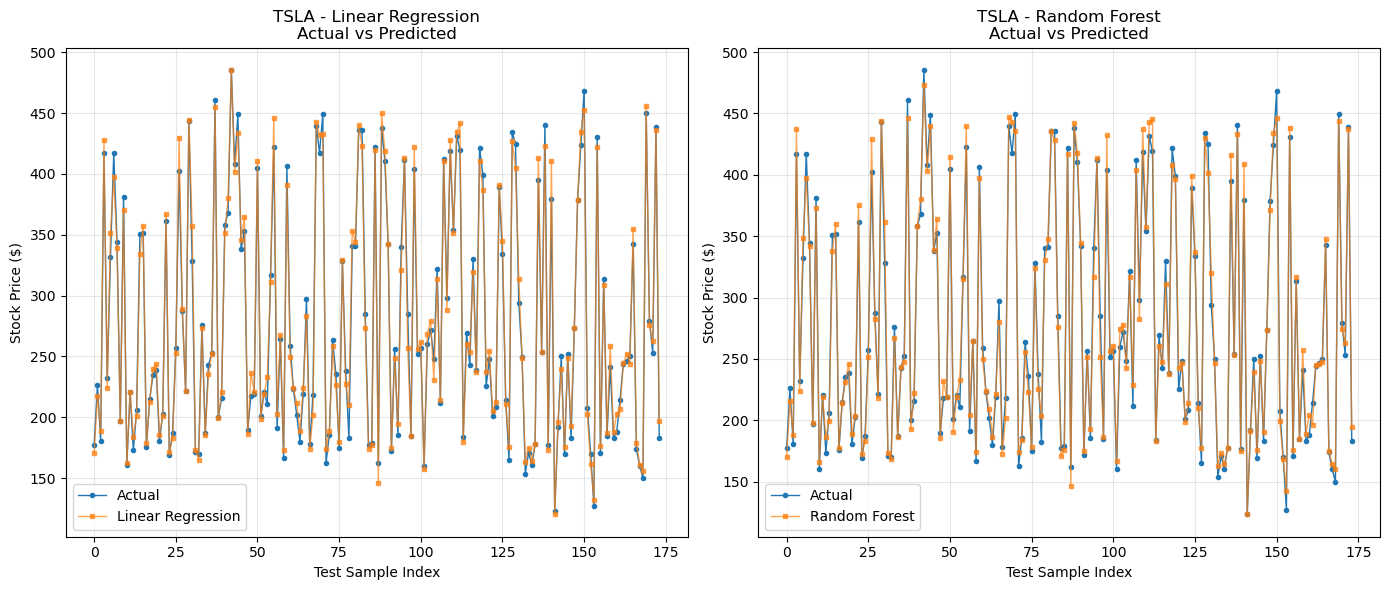

In [59]:
# Step 7: Plot actual vs predicted closing prices
print("\nGenerating visualization...")
plt.figure(figsize=(14, 6))

# Plot both models
plt.subplot(1, 2, 1)
plt.plot(range(len(y_test)), y_test.values, label='Actual', marker='o', markersize=3, linewidth=1)
plt.plot(range(len(y_test)), lr_pred, label='Linear Regression', marker='s', markersize=3, linewidth=1, alpha=0.7)
plt.xlabel('Test Sample Index')
plt.ylabel('Stock Price ($)')
plt.title(f'{stock_symbol} - Linear Regression\nActual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(len(y_test)), y_test.values, label='Actual', marker='o', markersize=3, linewidth=1)
plt.plot(range(len(y_test)), rf_pred, label='Random Forest', marker='s', markersize=3, linewidth=1, alpha=0.7)
plt.xlabel('Test Sample Index')
plt.ylabel('Stock Price ($)')
plt.title(f'{stock_symbol} - Random Forest\nActual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

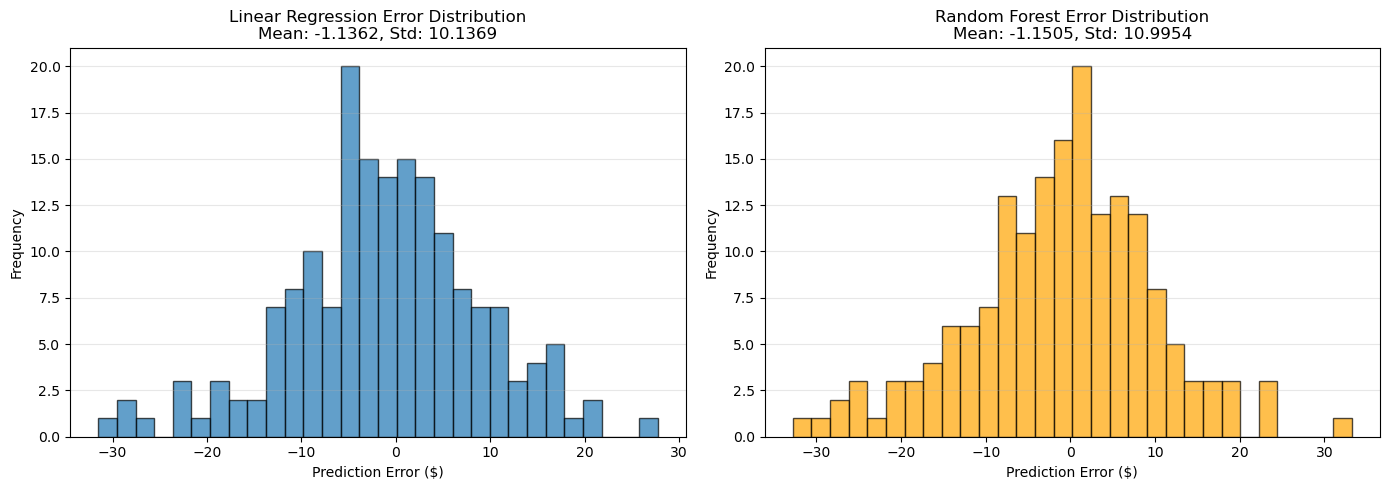

In [60]:
# Plot prediction errors
plt.figure(figsize=(14, 5))

lr_errors = y_test.values - lr_pred
rf_errors = y_test.values - rf_pred

plt.subplot(1, 2, 1)
plt.hist(lr_errors, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.title(f'Linear Regression Error Distribution\nMean: {np.mean(lr_errors):.4f}, Std: {np.std(lr_errors):.4f}')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.hist(rf_errors, bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.title(f'Random Forest Error Distribution\nMean: {np.mean(rf_errors):.4f}, Std: {np.std(rf_errors):.4f}')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Key Findings — TSLA Stock Prediction

- **Dataset & Range:** Historical TSLA data from 2023-01-01 to 2026-06-21 (868 rows fetched, 867 after shift for target).

- **Models Trained:** Linear Regression and Random Forest (n_estimators=100).

- **Performance (test set):**
  - Linear Regression — MSE: 104.05, RMSE: 10.20, R²: 0.9889
  - Random Forest — MSE: 122.22, RMSE: 11.06, R²: 0.9869
  - Observation: Both models fit the data well on the selected features; Linear Regression performed slightly better on the test split here.

- **Feature Importance (Random Forest):**
  1. High price — 50.55%
  2. Low price — 47.57%
  3. Open price — 1.56%
  4. Volume — 0.32%
  - Interpretation: Intraday price extremes (`High`, `Low`) are the dominant signals for predicting next-day Close in this setup.

- **Visual Assessment:** Actual vs predicted plots and error histograms show predictions closely tracking actual price movements with small residuals, but occasional spikes/errors remain.

- **Limitations & Caveats:**
  - This is a short-term, naive approach using only same-day OHLCV features to predict next-day Close; it does not model broader market context or news events.
  - High R² on historical test split does not guarantee future predictive performance; out-of-sample drift and regime changes can degrade accuracy.

- **Recommended Next Steps:**
  - Add lagged features (previous-day returns, moving averages) and technical indicators to capture temporal structure.
  - Run time-series-aware validation (rolling window / walk-forward) instead of random train/test split.
  - Perform hyperparameter tuning (GridSearch / RandomizedSearch) for Random Forest.
  - Consider ensemble methods or simple baseline persistence models for comparison.

- **Actionable Note:** If you want, I can implement lag features and rolling cross-validation next and evaluate improvements.